# Single-cell evaluation

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import sys, os
os.environ.setdefault("OPENCV_LOG_LEVEL", "ERROR")
import cv2
try:
    cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)
except AttributeError:
    pass
cwd = os.getcwd()
S2F_ROOT = os.path.normpath(os.path.join(cwd, ".."))
sys.path.insert(0, S2F_ROOT)
import torch
from data.cell_dataset import load_folder_data
from models.s2f_model import create_s2f_model
from utils.substrate_settings import compute_settings_normalization
from utils.metrics import evaluate_metrics_on_dataset, print_metrics_report, plot_predictions

## 1. Config

In [2]:
CHECKPOINT_PATH = os.path.join(S2F_ROOT, 'ckp', 'single_cell', 'ckp_singlecell_GN.pth')
DATA_FOLDER = os.path.normpath(os.path.join(S2F_ROOT, 'dataset', 'singlecell', 'test'))
IMAGE_SIZE = 1024
BATCH_SIZE = 2
THRESHOLD = 0.0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SUBSTRATE = 'fibroblasts_PDMS' # check in config/substrate_settings.json

## 2. Load model and weights (S2FGenerator)

In [3]:
generator, _ = create_s2f_model(in_channels=3, model_type='s2f')
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

generator.load_state_dict(checkpoint.get('generator_state_dict'), strict=True)
generator = generator.to(DEVICE)
_ = generator.eval()

## 3. Load data

Folder path containing images for inference (subfolders with `BF_001.tif` and `*_gray.jpg`).

In [4]:
val_loader = load_folder_data(
    DATA_FOLDER,
    substrate=SUBSTRATE,
    img_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    return_metadata=True,
)
print(f"Val samples: {len(val_loader.dataset)}")

Val samples: 46


## 4. Plot predictions

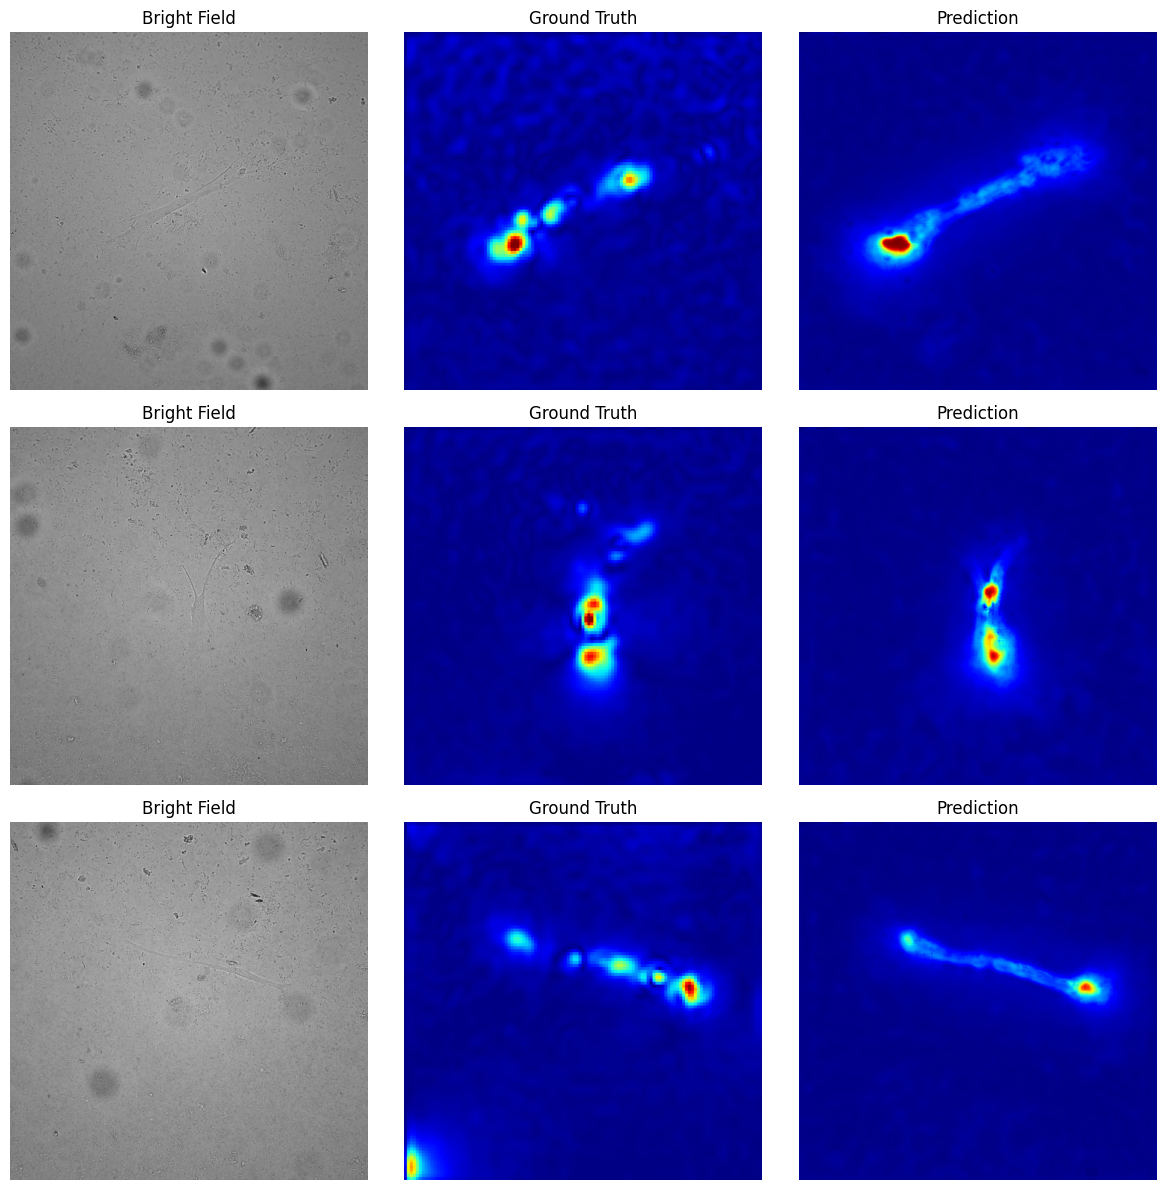

In [5]:
config_path = os.path.join(S2F_ROOT, 'config', 'substrate_settings.json')
normalization_params = compute_settings_normalization(config_path=config_path) 
plot_predictions(
    val_loader,
    generator,
    n_samples=3,
    device=DEVICE,
    use_settings=True,
    normalization_params=normalization_params,
    config_path=config_path,
    substrate_override=SUBSTRATE,
)

## 5. Evaluation

In [6]:
val_results = evaluate_metrics_on_dataset(
    generator,
    val_loader,
    device=DEVICE,
    description="Evaluating",
    save_predictions=True,
    threshold=THRESHOLD,
    use_settings=True,
    normalization_params=normalization_params,
    config_path=config_path,
    substrate_override=SUBSTRATE,
)
report = {'validation': val_results}
print_metrics_report(report)

Evaluating: 100%|██████████| 23/23 [00:13<00:00,  1.74it/s]


🔸 VALIDATION SET METRICS
------------------------------------------------------------
HEATMAP METRICS:
 MSE:             0.006318 ± 0.003792
 MS-SSIM:         0.8971 ± 0.0329
 Pixel Corr:      0.7548 ± 0.0851
 Correlation (Magnitude): 0.7473 ± 0.0497
 Relative Magnitude Error: 0.5873 ± 0.0559
FORCE SUM CORRELATION:
 Correlation: 0.7136
 GT Mean: 55964.97 ± 28028.24
 Pred Mean: 36473.96 ± 13871.01
